# EDA,DATA CLEANING 

#### import liabraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

In [4]:
import warnings
warnings.filterwarnings('ignore')

#### import dataset

In [5]:
dataset=pd.read_excel('dataset.xlsx')

#### EDA process

In [6]:
dataset.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [7]:
dataset.shape


(1440, 3)

In [8]:
dataset['review'] = (
    dataset['title'].fillna('').astype(str) + '  :  ' +
    dataset['body'].fillna('').astype(str)
)
dataset = dataset.drop([ 'body'], axis=1)

In [9]:
# REMOVE EMPTY
dataset = dataset[dataset['review'].str.strip() != ""]



In [10]:
# REMOVE NON-ENGLISH (Marathi etc.)
dataset = dataset[dataset['review'].str.contains(r'[a-zA-Z]', regex=True)]

In [11]:
dataset.isnull().sum()

title     0
rating    0
review    0
dtype: int64

In [12]:
dataset.dropna(inplace=True)

In [13]:
dataset.drop_duplicates(inplace=True)
dataset.shape


(1438, 3)

In [14]:
for col in dataset.columns:
    print('=============================')
    print(f"Column: {col}")
    
    print("Data Type:", dataset[col].dtype)
    print("Missing Values:", dataset[col].isnull().sum())
    print("Unique Values:", dataset[col].nunique())
    
    print("Top Values:")
    print(dataset[col].value_counts().head(5))
    
    print('=============================')
    

Column: title
Data Type: object
Missing Values: 0
Unique Values: 1349
Top Values:
title
Value for money    16
Average             6
Good                6
Waste of money      6
Good product        5
Name: count, dtype: int64
Column: rating
Data Type: int64
Missing Values: 0
Unique Values: 5
Top Values:
rating
5    419
1    384
4    310
3    199
2    126
Name: count, dtype: int64
Column: review
Data Type: object
Missing Values: 0
Unique Values: 1438
Top Values:
review
Horrible product  :  Very disappointed with the overall performance from Samsung                                                                                                                                                                                                                                  1
medium product  :  not satisfied in camera quality, and battery lifenot real 48mp camera.. and battery life is one and half day only but rarely used mobile my family.. total waste for money,, and worst samsung product of 

In [15]:
def get_sentiment(rating):
    if rating>=4:
        return 'POSITIVE'
    elif rating==3:
        return 'NEUTRAL'
    else:
        return 'NAGATIVE'

In [16]:
dataset['Sentiment']=dataset['rating'].apply(get_sentiment)

In [17]:
print('sentiment Distribution:-')
print(dataset['Sentiment'].value_counts())

sentiment Distribution:-
Sentiment
POSITIVE    729
NAGATIVE    510
NEUTRAL     199
Name: count, dtype: int64


#### frequency distribution between sentiments

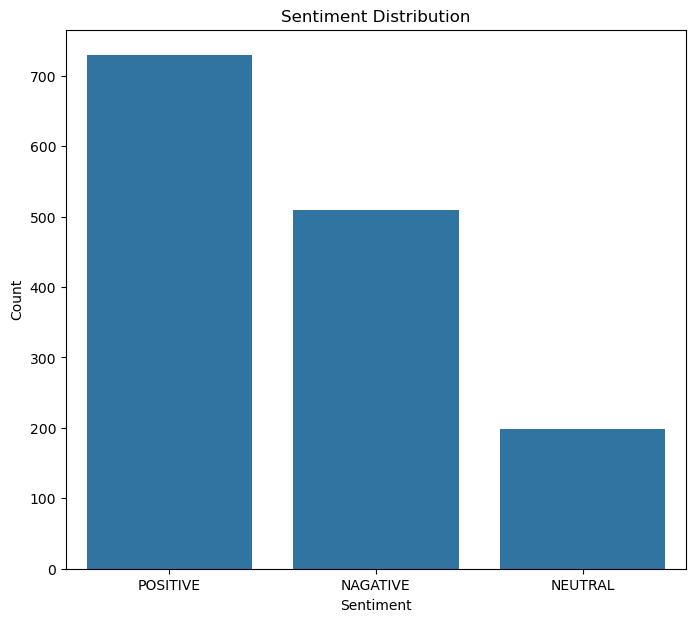

In [18]:
plt.figure(figsize=(8,7))
sns.barplot( dataset['Sentiment'].value_counts())
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [19]:
dataset['review_length']=dataset['review'].apply(lambda x:len(str(x)))

In [20]:
dataset.head()

,title,rating,review,Sentiment,review_length
0,Horrible product,1,Horrible product : Very disappointed with th...,NAGATIVE,80
1,Camera quality is not like 48 megapixel,3,Camera quality is not like 48 megapixel : Ca...,NEUTRAL,65
2,Overall,4,"Overall : Got the mobile on the launch date,...",POSITIVE,415
3,A big no from me,1,A big no from me : 1. It doesn't work with 5...,NAGATIVE,398
4,Put your money somewhere else,1,Put your money somewhere else : Not worth bu...,NAGATIVE,213


In [21]:
print("\nReview Length Stats:\n")
print(dataset['review_length'].describe())


Review Length Stats:

count    1438.000000
mean      337.269819
std       229.243902
min        13.000000
25%       202.000000
50%       281.000000
75%       399.000000
max      2540.000000
Name: review_length, dtype: float64


#### find distribution ,skewness between datset

<Figure size 800x700 with 0 Axes>

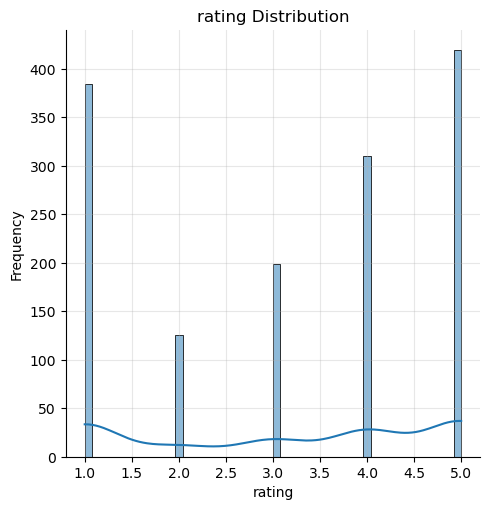

<Figure size 800x700 with 0 Axes>

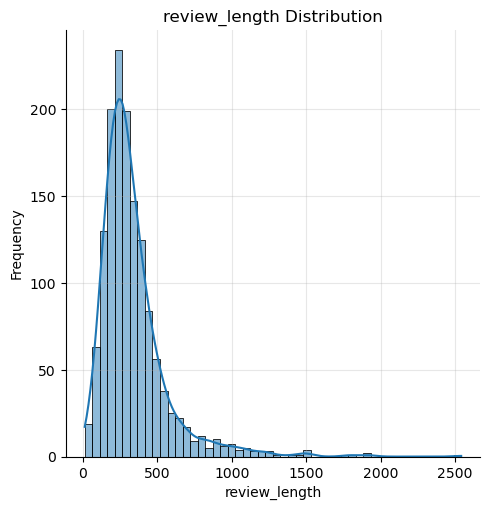

In [22]:
num_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(8,7))
    sns.displot(dataset[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

#### outlier handling

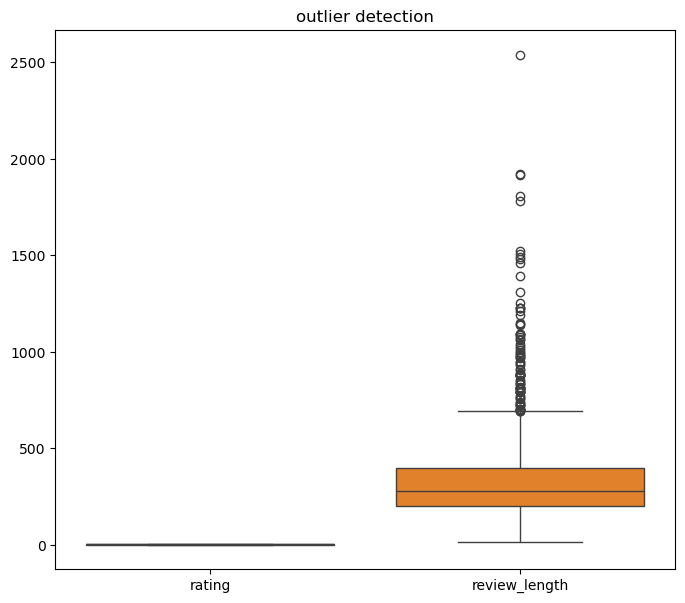

In [23]:
plt.figure(figsize=(8,7))
sns.boxplot(data=dataset[num_cols])
plt.title('outlier detection')
plt.show()

In [24]:
Q1 = dataset[num_cols].quantile(0.25)
Q3 = dataset[num_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [25]:
for col in num_cols:
    lower = lower_bound[col]
    upper = upper_bound[col]
    
    dataset[col] = dataset[col].clip(lower, upper)

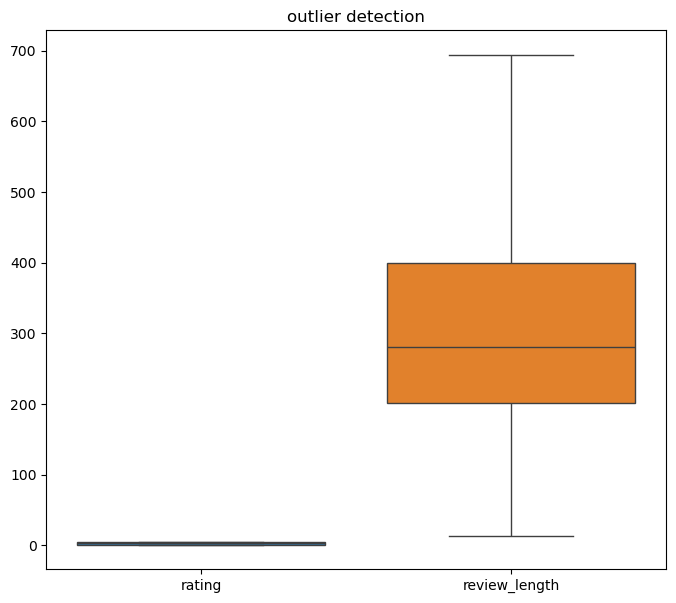

In [26]:
plt.figure(figsize=(8,7))
sns.boxplot(data=dataset[num_cols])
plt.title('outlier detection')
plt.show()

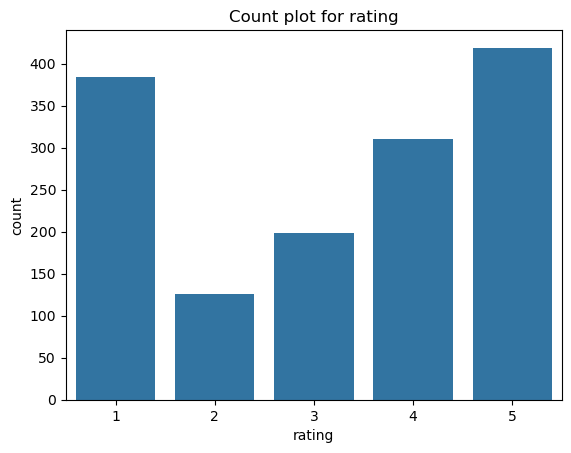

In [27]:
sns.countplot(data=dataset, x='rating')
plt.title('Count plot for rating')
plt.show()

In [ ]:
sns.pairplot(data=dataset)
plt.show()

In [ ]:

nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_review(text):

    text = str(text).lower()

    # REMOVE URL
    text = re.sub(r'http\S+', '', text)

    # REMOVE HTML
    text = re.sub(r'<.*?>', '', text)

    # REMOVE EMOJIS
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+",
        '',
        text
    )

    # REMOVE SHAPES / SYMBOLS
    text = re.sub(
        r'[■□▲△▶►▼◆●★☆✓✔✕✖♦•]',
        '',
        text
    )

    # REMOVE SPECIAL CHARACTERS
    text = re.sub(
        r'[^a-zA-Z]',
        ' ',
        text
    )

    # TOKENIZATION
    words = text.split()

    # REMOVE SMALL WORDS
    words = [
        w for w in words
        if len(w) > 2
    ]

    # REMOVE STOPWORDS
    words = [
        w for w in words
        if w not in stop_words
    ]

    # LEMMATIZATION
    words = [
        lemmatizer.lemmatize(w)
        for w in words
    ]
    return " ".join(words)

In [ ]:
# tokenization
dataset['tokens'] = dataset['review'].apply(clean_review)

In [ ]:
# clean_text
dataset['clean_review']=dataset['tokens'].apply(lambda x:" ".join(x))

In [ ]:
# WORD FREQUENCY
all_words = []
for t in dataset['tokens']:
    all_words.extend(t)

freq = Counter(all_words)

print("Top Words:", freq.most_common(10))

Top Words: [(' ', 44950), ('e', 34024), ('a', 22148), ('o', 20400), ('r', 17861), ('t', 17834), ('n', 16779), ('i', 16393), ('s', 13869), ('l', 12650)]


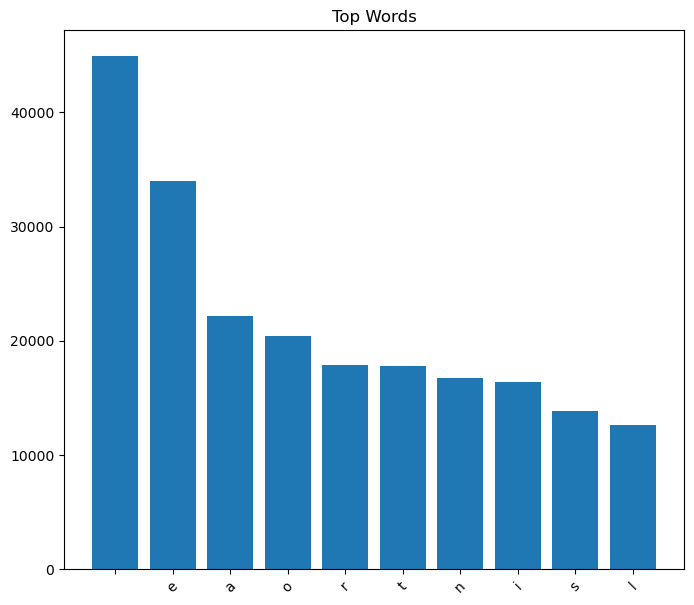

In [ ]:
# PLOT WORDS
top_words = freq.most_common(10)
words = [i[0] for i in top_words]
counts = [i[1] for i in top_words]

plt.figure(figsize=(8,7))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words")
plt.show()

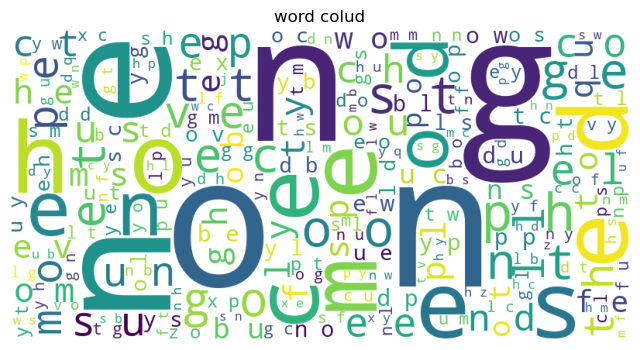

In [ ]:
#  word cloud
text=" ".join(dataset['clean_review'])
wordcloud=WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(8,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("word colud")
plt.show()

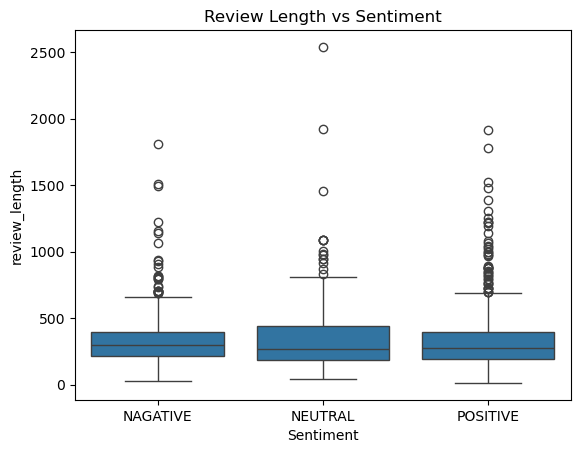

In [ ]:
# REVIEW LENGTH
dataset['review_length'] = dataset['review'].apply(len)

sns.boxplot(x='Sentiment', y='review_length', data=dataset)
plt.title("Review Length vs Sentiment")
plt.show()

In [ ]:
Q1 = dataset['review_length'].quantile(0.25)
Q3 = dataset['review_length'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
dataset['review_length'] = dataset['review_length'].clip(lower_bound, upper_bound)

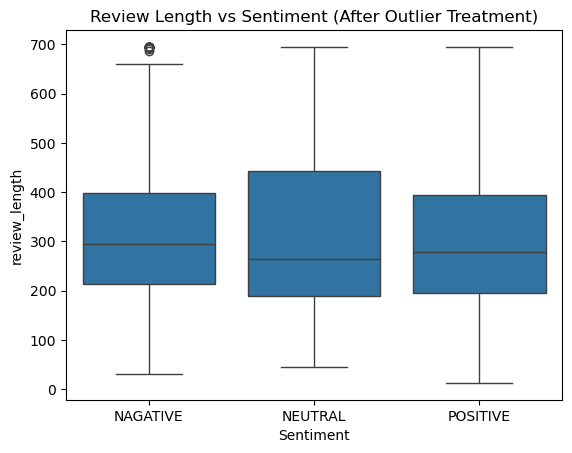

In [ ]:
sns.boxplot(x='Sentiment', y='review_length', data=dataset)
plt.title("Review Length vs Sentiment (After Outlier Treatment)")
plt.show()

In [ ]:
dataset.to_excel('clean_data.xlsx', index=False)

# MODEL BULDING

In [ ]:
import pandas as pd
import re
import pickle
import nltk

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
# models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
# metrics
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.metrics import classification_report,roc_curve,roc_auc_score
from sklearn.preprocessing import label_binarize

from gensim.models import Word2Vec

In [ ]:
dataset=pd.read_excel('clean_data.xlsx')
dataset.head()

,title,rating,review,Sentiment,review_length,tokens,clean_review
0,Horrible product,1,Horrible product : Very disappointed with th...,NAGATIVE,80.0,horrible product disappointed overall performa...,h o r r i b l e p r o d u c t d i s a p p ...
1,Camera quality is not like 48 megapixel,3,Camera quality is not like 48 megapixel : Ca...,NEUTRAL,65.0,camera quality like megapixel camera quality low,c a m e r a q u a l i t y l i k e m e g ...
2,Overall,4,"Overall : Got the mobile on the launch date,...",POSITIVE,415.0,overall got mobile launch date battery must ap...,o v e r a l l g o t m o b i l e l a u n ...
3,A big no from me,1,A big no from me : 1. It doesn't work with 5...,NAGATIVE,398.0,big work ghz wifi frequency ghz old school cam...,b i g w o r k g h z w i f i f r e q u ...
4,Put your money somewhere else,1,Put your money somewhere else : Not worth bu...,NAGATIVE,213.0,put money somewhere else worth buying faulty s...,p u t m o n e y s o m e w h e r e e l s ...


In [ ]:
stop_word=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

In [ ]:
def clean_review(text):

    text = str(text).lower()

    # REMOVE URL
    text = re.sub(r'http\S+', '', text)

    # REMOVE HTML
    text = re.sub(r'<.*?>', '', text)

    # REMOVE EMOJIS
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+",
        '',
        text)

    # REMOVE SHAPES / SYMBOLS
    text = re.sub(
        r'[■□▲△▶►▼◆●★☆✓✔✕✖♦•]',
        '',
        text )

    # REMOVE SPECIAL CHARACTERS
    text = re.sub(
        r'[^a-zA-Z]',
        ' ',
        text
    )

    # TOKENIZATION
    words = text.split()

    # REMOVE SMALL WORDS
    words = [
        w for w in words
        if len(w) > 2]

    # REMOVE STOPWORDS
    words = [
        w for w in words
        if w not in stop_words]

    # LEMMATIZATION
    words = [
        lemmatizer.lemmatize(w)
        for w in words ]

    return " ".join(words)

In [ ]:
# =========================
# CLEAN REVIEW
# =========================
dataset['clean_review']=dataset['review'].apply(clean_review)

In [ ]:
# =========================
# WORD2VEC
# =========================
tokens=dataset['clean_review'].apply(lambda x:x.split())

In [ ]:
word2vec_model=Word2Vec(
    sentences=tokens,
    vector_size=100,
    window=5,
    min_count=2
)

In [ ]:
print(word2vec_model.wv.most_similar('good'))

[('battery', 0.9993934631347656), ('life', 0.9993663430213928), ('camera', 0.9992866516113281), ('awesome', 0.9992703795433044), ('backup', 0.9992480278015137), ('quality', 0.9991915822029114), ('nice', 0.9991751909255981), ('mah', 0.9990126490592957), ('excellent', 0.9989460110664368), ('average', 0.9989371299743652)]


In [ ]:
# =========================
# TF-IDF
# =========================
vectorizer=TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.85,
    sublinear_tf=True
)
x=vectorizer.fit_transform(dataset['clean_review'])
y=dataset['Sentiment']

In [ ]:
# split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
# Logistic regression 
log_model=LogisticRegression(max_iter=1000)
log_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# prediction

log_pred=log_model.predict(x_test)

In [ ]:
# evaluation
print('LOGISTIC REGRESSION :-')
print("Train Accuracy:")
print(log_model.score(x_train, y_train)*100)

print("Test Accuracy:")
print(log_model.score(x_test, y_test)*100)

print('classification matrix')
print(classification_report(y_test,log_pred))

LOGISTIC REGRESSION :-
Train Accuracy:
87.82608695652175
Test Accuracy:
77.43055555555556
classification matrix
              precision    recall  f1-score   support

    NAGATIVE       0.81      0.83      0.82       101
     NEUTRAL       0.50      0.02      0.04        45
    POSITIVE       0.76      0.97      0.85       142

    accuracy                           0.77       288
   macro avg       0.69      0.61      0.57       288
weighted avg       0.74      0.77      0.71       288



In [ ]:
log_acc=accuracy_score(y_test,log_pred)

In [ ]:
# NAIVE BAYES
nb_model=MultinomialNB()
nb_model.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [ ]:
nb_pred=nb_model.predict(x_test)

In [ ]:
print("NAIVE BAYES")
print("Train Accuracy:")
print(nb_model.score(x_train, y_train)*100)

print("Test Accuracy:")
print(nb_model.score(x_test, y_test)*100)

print('classification matrix')
print(classification_report(y_test,nb_pred))


NAIVE BAYES
Train Accuracy:
81.21739130434783
Test Accuracy:
75.69444444444444
classification matrix
              precision    recall  f1-score   support

    NAGATIVE       0.85      0.78      0.81       101
     NEUTRAL       0.00      0.00      0.00        45
    POSITIVE       0.71      0.98      0.82       142

    accuracy                           0.76       288
   macro avg       0.52      0.59      0.55       288
weighted avg       0.65      0.76      0.69       288



In [ ]:
nb_acc=accuracy_score(y_test,nb_pred)

In [ ]:
# linear SVC
svc_model=LinearSVC()
svc_model.fit(x_train,y_train)
svc_pred=svc_model.predict(x_test)

In [ ]:
print("LINEAR SVC")
print("Train Accuracy:")
print(svc_model.score(x_train, y_train)*100)

print("Test Accuracy:")
print(svc_model.score(x_test, y_test)*100)

print('classification matrix')
print(classification_report(y_test,svc_pred))

LINEAR SVC
Train Accuracy:
99.39130434782608
Test Accuracy:
76.04166666666666
classification matrix
              precision    recall  f1-score   support

    NAGATIVE       0.80      0.81      0.80       101
     NEUTRAL       0.36      0.11      0.17        45
    POSITIVE       0.77      0.93      0.84       142

    accuracy                           0.76       288
   macro avg       0.64      0.62      0.61       288
weighted avg       0.72      0.76      0.72       288



In [ ]:
svc_acc=accuracy_score(y_test,svc_pred)

In [ ]:
# RANDOM FOREST
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

In [ ]:
print("RANDOM FOREST")
print("Train Accuracy:")
print(rf_model.score(x_train, y_train)*100)

print("Test Accuracy:")
print(rf_model.score(x_test, y_test)*100)

print('classification matrix')
print(classification_report(y_test,rf_pred))

RANDOM FOREST
Train Accuracy:
100.0
Test Accuracy:
75.34722222222221
classification matrix
              precision    recall  f1-score   support

    NAGATIVE       0.82      0.78      0.80       101
     NEUTRAL       0.00      0.00      0.00        45
    POSITIVE       0.72      0.97      0.83       142

    accuracy                           0.75       288
   macro avg       0.52      0.58      0.54       288
weighted avg       0.64      0.75      0.69       288



In [ ]:
rf_acc=accuracy_score(y_test,rf_pred)

#### model comparision

In [ ]:
model=[
    'Logistic Regression',
    'Naive Bayes',
    'Linear SVC',
    'Random Forest'
]
accuracy = [
    log_acc,
    nb_acc,
    svc_acc,
    rf_acc
]

In [ ]:
result=pd.DataFrame({
    'Model':model,
    'Accuracy':accuracy
})
print(result)

                 Model  Accuracy
0  Logistic Regression  0.774306
1          Naive Bayes  0.756944
2           Linear SVC  0.760417
3        Random Forest  0.753472


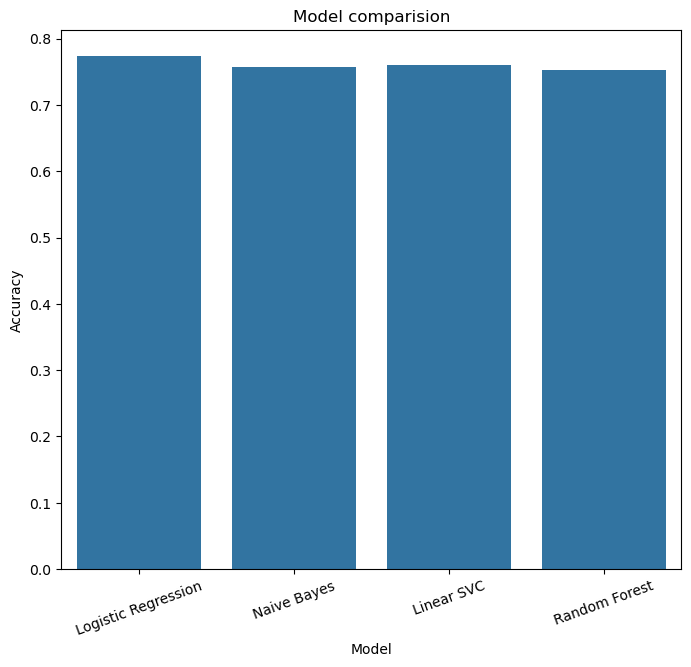

In [ ]:
# boxplot
plt.figure(figsize=(8,7))
sns.barplot(
    x='Model',
    y='Accuracy',
    data=result
)
plt.title('Model comparision')
plt.xticks(rotation=20)
plt.show()

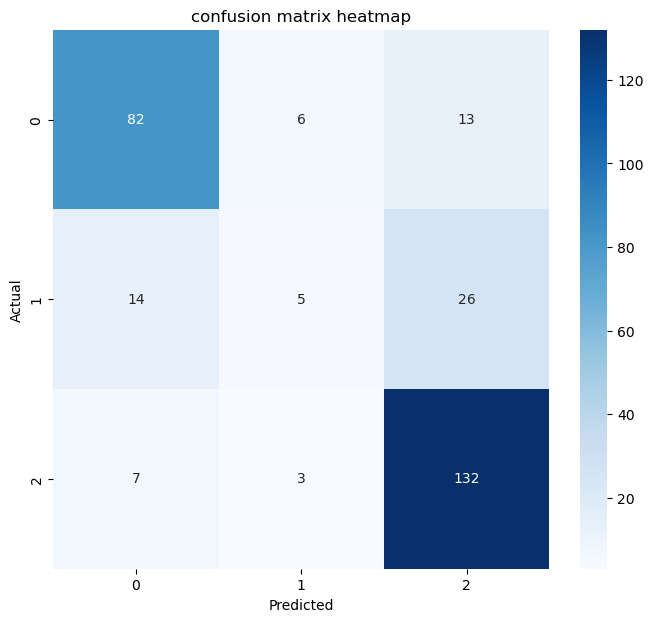

In [ ]:
# confusion matrix
cm=confusion_matrix(y_test,svc_pred)
plt.figure(figsize=(8,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion matrix heatmap")
plt.show()

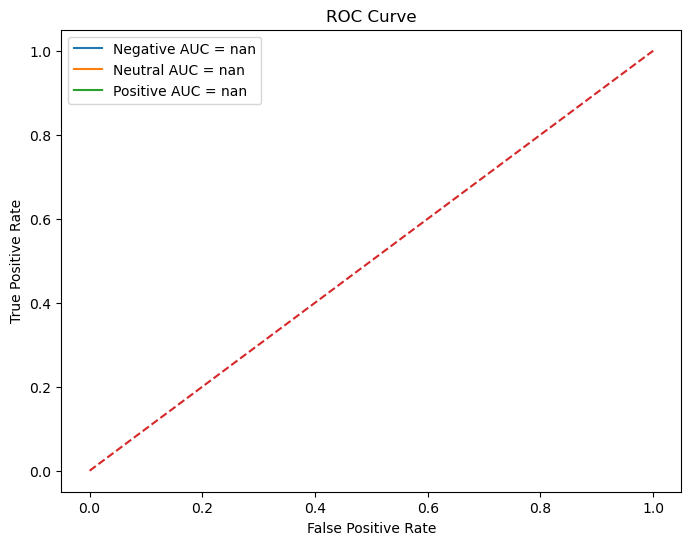

In [ ]:
classes = ['Negative', 'Neutral', 'Positive']

y_test_bin = label_binarize(
    y_test,
    classes=classes
)
# logistic regression roc
log_prob = log_model.predict_proba(x_test)

plt.figure(figsize=(8,6))
for i in range(len(classes)):
    fpr, tpr, threshold = roc_curve(
        y_test_bin[:, i],
        log_prob[:, i]
    )

    auc_score = roc_auc_score(
        y_test_bin[:, i],
        log_prob[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{classes[i]} AUC = {auc_score:.2f}"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# =========================
# SAVE MODEL
# =========================
pickle.dump(
    svc_model,
    open('model.pkl','wb')
)

In [ ]:
pickle.dump(
    vectorizer,
    open('vectorizer.pkl','wb')
)
print ('Best Model Saved')

Best Model Saved
